In [ ]:
%%capture
!pip install -U corus==0.10.0 tiktoken==0.10.0 youtokentome==1.0.6 sentence_transformers==5.0.0 numpy==2.0.2 matplotlib==3.10.0 torch==2.6.0+cu124 transformers==4.55.0 datasets==4.0.0

In [ ]:
%%capture
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

In [ ]:
from corus import load_lenta

path = 'lenta-ru-news.csv.gz'
records = load_lenta(path)
next(records)

In [ ]:
dataset = [next(records).text for i in range(1000)]
dataset[0]

## Токенизация

Токенизация — процесс предобработки входного текста в список токенов. Обычно далее каждый токен векторизуется, и весь этот массив векторов подаётся модели на вход, с чем она начинает работать.

В моделях архитектуры Transformer токенизаторы обучаемы. Обучение токенизаторов не схоже с тем, как обучаются ML-модели, наоборот, это статистический процесс, который определяет, какие сочетания символов (подслов, слов) лучше всего выбрать для корпуса текста, с которым мы работаем.

### BPE

BPE активно используется в GPT-like моделях, обучается слиянием символов из основного корпуса, выбирая пары по наибольшей частоте встречаемости

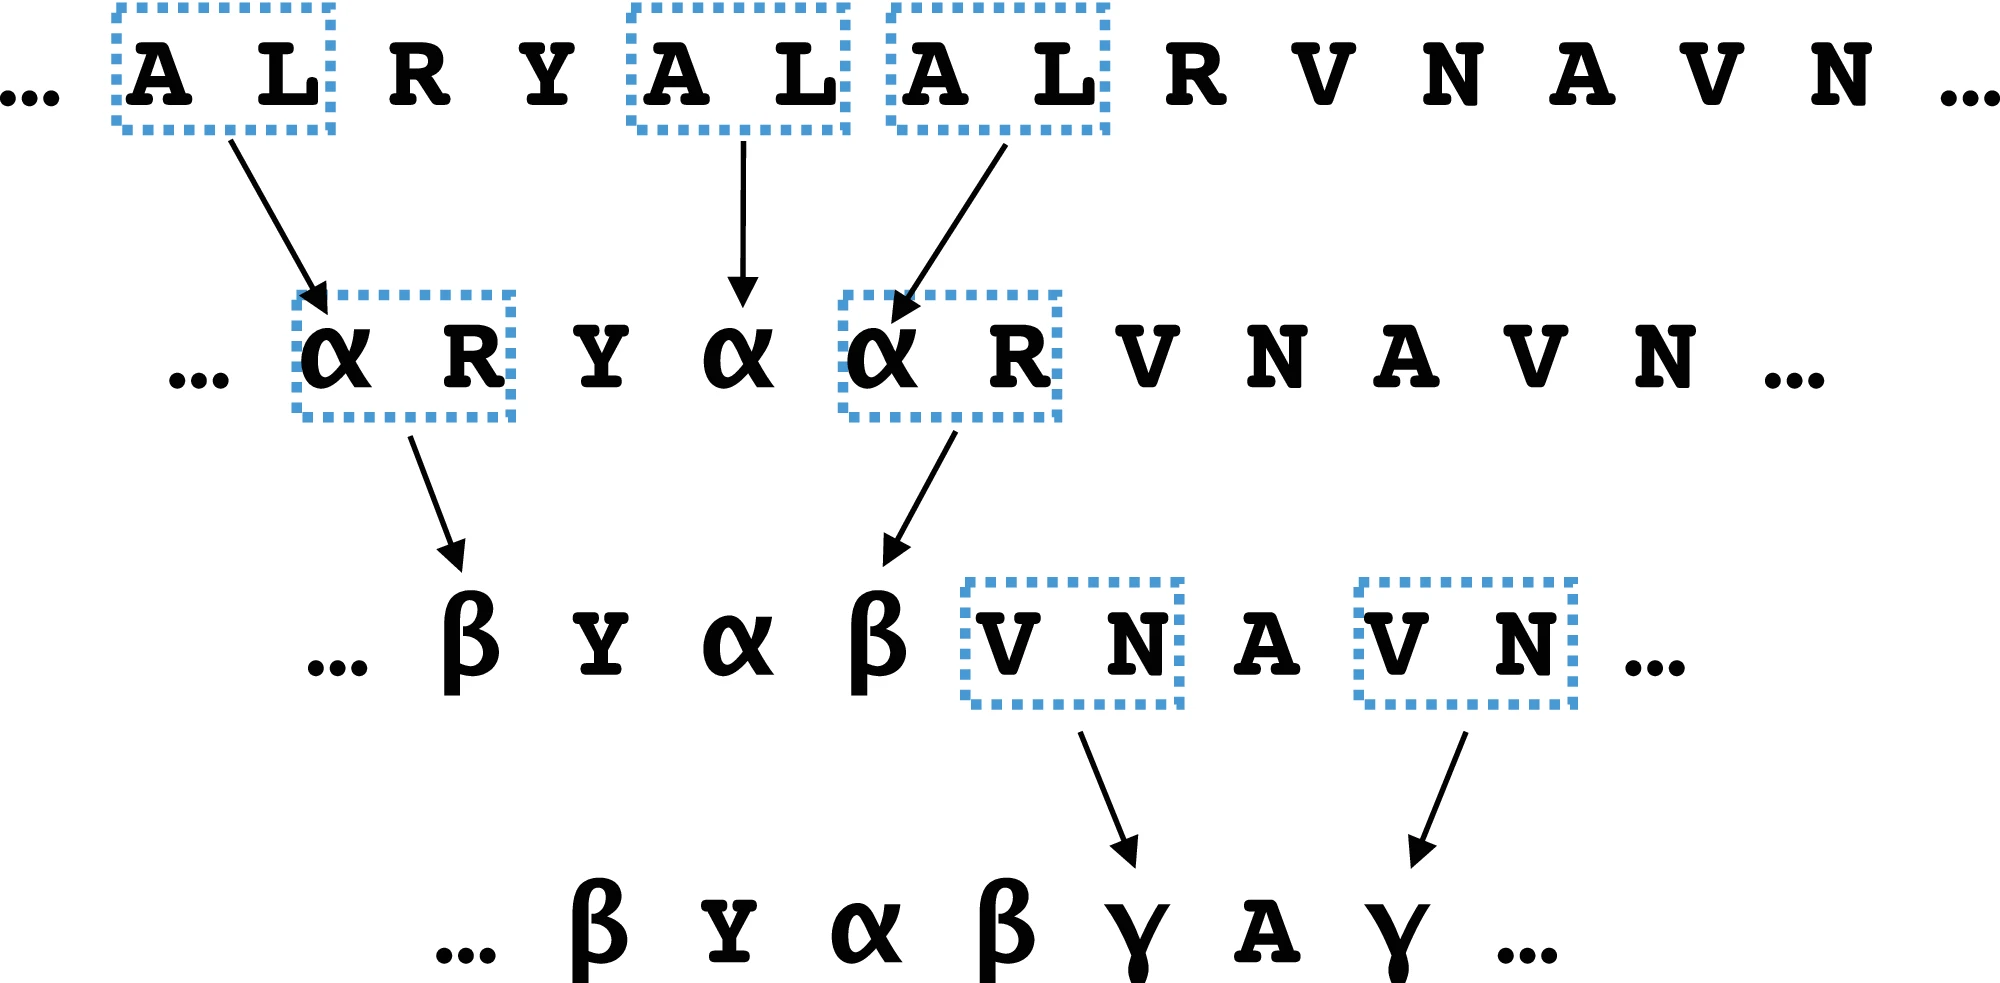

#### Нужен ли препроцессинг?

GPT-2 [encoder.py](https://github.com/openai/gpt-2/blob/master/src/encoder.py) - GPT-2 BPE для инференса

In [ ]:
import regex as re

gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

print(re.findall(gpt2pat, "Hi, how are you? I'm fine. qwe123   test"))

['Hi', ',', ' how', ' are', ' you', '?', ' I', "'m", ' fine', '.', ' qwe', '123', '  ', ' test']


#### Tiktoken

[tiktoken](https://github.com/openai/tiktoken) - `is a fast BPE tokeniser for use with OpenAI's models`


Основная задача tiktoken — разбивать текст на токены (фрагменты текста), которые используются языковыми моделями для обработки и генерации текста.

Алгоритм BPE обеспечивает обратимость операции (можно восстановить исходный текст по токенам) и эффективное кодирование слов и подслов, в том числе тех, которых не было в обучающем наборе.

tiktoken поддерживает разные схемы кодирования — для моделей GPT-4, GPT-3.5, Codex, и других.

С помощью tiktoken можно:

- Определять количество токенов в тексте

- Кодировать и декодировать текст


##### Encode/decode

In [ ]:
import tiktoken

enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode("    hello world!!!")
print(tokens)

[220, 220, 220, 23748, 995, 10185]


In [ ]:
len(tokens)

6

In [ ]:
enc.decode(tokens)

'    hello world!!!'

#### YouTokenToMe

[YouTokenToMe](https://github.com/vkcom/YouTokenToMe) представляет собой  текстовый токенизатор, ориентированный на эффективность вычислений. В настоящее время он реализует Byte Pair Encoding  (BPE). Эта реализация намного быстрее в обучении и токенизации, чем Hugging Face, fastBPE и SentencePiece. В некоторых тестовых случаях она работает в 90 раз быстрее.

In [ ]:
import youtokentome as yttm

In [ ]:
with open('dataset.txt', "w") as f:
    for i in range(1000):
        print(dataset[i], file=f)

In [ ]:
%%time
model_name = 'bpe_vk.model'
yttm.BPE.train(data='dataset.txt', vocab_size=5000, model=model_name)

CPU times: user 394 ms, sys: 104 ms, total: 498 ms
Wall time: 321 ms


In [ ]:
bpe = yttm.BPE(model=model_name)
print(bpe.encode([dataset[0]], output_type=yttm.OutputType.ID))

[[1985, 4588, 587, 2396, 355, 769, 212, 236, 839, 198, 3682, 300, 323, 1080, 827, 476, 2269, 2998, 200, 245, 243, 4738, 4862, 797, 1692, 409, 375, 1282, 202, 480, 14, 440, 186, 244, 559, 1861, 497, 33, 2754, 472, 202, 3128, 1364, 266, 227, 899, 2879, 477, 312, 2881, 216, 604, 18, 243, 1633, 187, 839, 2941, 3434, 1553, 2909, 1240, 2582, 1320, 265, 1827, 275, 546, 17, 18, 524, 236, 231, 341, 2281, 669, 900, 3327, 4241, 736, 3715, 1651, 231, 808, 443, 3946, 1694, 314, 278, 1006, 198, 186, 202, 480, 210, 699, 29, 4185, 360, 238, 2280, 4357, 189, 357, 108, 106, 128, 66, 499, 236, 639, 261, 2622, 228, 4389, 264, 3096, 2998, 200, 245, 577, 1319, 814, 1977, 10, 2378, 751, 209, 1448, 22, 389, 4582, 3108, 524, 209, 24, 287, 4817, 186, 192, 300, 3240, 440, 186, 4870, 3729, 957, 911, 956, 2223, 4357, 1515, 3826, 25, 658, 4892, 3468, 696, 186, 407, 679, 191, 4207, 187, 415, 1689, 1307, 4150, 1248, 3525, 2807, 200, 417, 951, 193, 299, 3308, 376, 198, 2647, 499, 1525, 4928, 186, 1296, 480, 1528, 2737

In [ ]:
print(bpe.encode([dataset[0]], output_type=yttm.OutputType.SUBWORD))

[['▁Ав', 'стрий', 'ские', '▁правоохранитель', 'ные', '▁орга', 'ны', '▁не', '▁представи', 'ли', '▁доказа', 'тель', 'ств', '▁нару', 'шения', '▁россий', 'скими', '▁биатло', 'ни', 'ста', 'ми', '▁антидо', 'пинговых', '▁прави', 'л.', '▁Об', '▁этом', '▁сообщил', '▁по', 'со', 'л', '▁России', '▁в', '▁В', 'ене', '▁Дмитрий', '▁Л', 'ю', 'бин', 'ский', '▁по', '▁итогам', '▁встре', 'чи', '▁у', 'пол', 'номо', 'чен', 'ного', '▁адвока', 'та', '▁ди', 'п', 'ми', 'ссии', '▁с', '▁представи', 'телями', '▁прокура', 'туры', '▁страны,', '▁передает', '▁ТАСС.', '▁«Д', 'ей', 'ствует', '▁пре', 'зу', 'м', 'п', 'ция', '▁не', 'ви', 'нов', 'ности.', '▁Ка', 'ких', '-либо', '▁огранич', 'ений', '▁свободы', '▁перед', 'ви', 'жения', '▁для', '▁команды', '▁нет', '»,', '▁—', '▁добави', 'ли', '▁в', '▁по', 'со', 'ль', 'стве', '.', '▁Международ', 'ный', '▁со', 'юз', '▁биатлонист', 'ов', '▁(', 'I', 'B', 'U', ')', '▁также', '▁не', '▁будет', '▁при', 'меня', 'ть', '▁санкции', '▁к', '▁российским', '▁биатло', 'ни', 'ста', 'м.', '▁Все',

#### transformers AutoTokenizer

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

text = "Hello, how are you?"
encoded_input = tokenizer(text)
encoded_input

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

{'input_ids': [15496, 11, 703, 389, 345, 30], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "Hello, how are you?"
print(tokenizer(text))
print(tokenizer(text, padding="max_length"))
print(tokenizer(text, text, add_special_tokens=True))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}
{'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Важность токенизации и распространенные проблемы

- Токенизация напрямую влияет на стоимость использования любой модели, а также на длину контекста и количество вычислений
- Правильно токенизированная последовательность также сильно влияет на качество модели из-за появления символов, которых модель не видела или из-за особенностей некоторых языков, где нет, например, пробелов

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
print(model.tokenizer.vocab_size)

tokenized_data = model.tokenize(["tokenizer tokenizes text into tokens"])
tokens = model.tokenizer.convert_ids_to_tokens(tokenized_data["input_ids"][0])
print(tokens)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

30522
['[CLS]', 'token', '##izer', 'token', '##izes', 'text', 'into', 'token', '##s', '[SEP]']


#### Непоследовательные разбиения

In [ ]:
minilm_tokenizer = model.tokenizer._tokenizer
print(minilm_tokenizer.encode("unsophisticated sophisticated").tokens)

['[CLS]', 'un', '##sop', '##his', '##tica', '##ted', 'sophisticated', '[SEP]']


#### Emoji и неизвестные токены

In [ ]:
# all-MiniLM-L6-v2
print(minilm_tokenizer.encode("You can break it 😞").tokens)

# tiktoken/OpenAI
enc = tiktoken.encoding_for_model("gpt-4o")
token_data = enc.encode("You can break it 😞")
tokens = [enc.decode_single_token_bytes(number) for number in token_data]
print(tokens)

['[CLS]', 'you', 'can', 'break', 'it', '[UNK]', '[SEP]']
[b'You', b' can', b' break', b' it', b' \xf0\x9f\x98', b'\x9e']


#### Языковая несправедливость

[tiktokenizer demo](https://tiktokenizer.vercel.app/)

In [ ]:
token_data = enc.encode("кот ел котлету")
[enc.decode([token]) for token in token_data]

['кот', ' ел', ' кот', 'лет', 'у']

#### Опечатки

In [ ]:
token_data = enc.encode("I hve received wrong pckage")
[enc.decode([token]) for token in token_data]

['I', ' h', 've', ' received', ' wrong', ' p', 'ck', 'age']

### Оценка качества токенизации

In [ ]:
import re, time, random
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

In [ ]:
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 100)

In [ ]:
data = {
    "news": [
        "Минфин сообщил, что дефицит бюджета в первом квартале оказался ниже ожиданий аналитиков.",
        "Власти региона запустили пилотный проект по цифровому мониторингу общественного транспорта и пассажиропотока.",
        "Суд продлил меру пресечения бывшему директору компании по делу о поставках оборудования для госзаказа.",
        "Экспорт зерна вырос на 12 процентов, однако логистические ограничения по-прежнему сдерживают темпы отгрузок.",
        "Исследователи из университета представили новую модель для анализа медицинских изображений и клинических записей.",
        "На пленарной сессии форума эксперты обсудили инфляцию, курс рубля, промышленную политику и импортозамещение."
    ],
    "support": [
        "Здравствуйте, у меня второй день не открывается личный кабинет: после ввода кода 731944 появляется ошибка 502 и пустой экран.",
        "Не могу оплатить заказ ORD-99127 картой Мир, приложение пишет «операция отклонена», хотя деньги на счете есть.",
        "После обновления приложения пропали сохраненные адреса доставки и история заказов. Что можно сделать?",
        "Добрый день! Мне пришел не тот товар по заказу №45281, нужен возврат и новая накладная на обмен.",
        "Пожалуйста, проверьте тикет TKT-2026-1187: бот закрыл обращение автоматически, но проблема с подпиской не решена.",
        "Уточните, почему счет 2026/03-155 выставлен дважды и как отменить автосписание на следующий месяц."
    ],
    "ecommerce": [
        "Смартфон 8/256 ГБ, AMOLED 120 Гц, NFC, быстрая зарядка 67 Вт, гарантия 12 месяцев.",
        "Зимняя куртка мужская, мембрана 10000/10000, утеплитель 250 г/м2, цвет графит, размер 52.",
        "Кофемашина автоматическая, давление 19 бар, капучинатор, контейнер для зерен 250 г, артикул CM-450X.",
        "Ноутбук для работы и учебы: 16 ГБ RAM, SSD 512 ГБ, Ryzen 7, подсветка клавиатуры, вес 1.45 кг.",
        "Книга по машинному обучению: практические примеры на Python, главы про трансформеры, эмбеддинги и RAG.",
        "Набор детского конструктора 124 детали, безопасный пластик, возраст 6+, рейтинг 4.8, 238 отзывов."
    ],
    "finance_legal": [
        "Банк вправе запросить документы, подтверждающие происхождение средств, в рамках требований 115-ФЗ.",
        "Процентная ставка по вкладу составляет 15.2% годовых при размещении средств на срок 181 день.",
        "В договоре поставки №DP-48/26 необходимо уточнить порядок приемки товара и сроки направления претензий.",
        "Клиент дал согласие на обработку персональных данных, включая передачу сведений уполномоченным лицам.",
        "Сумма ежемесячного платежа по кредиту — 42 590 ₽, дата списания — 17-е число каждого месяца.",
        "Компания оспаривает доначисление налога, ссылаясь на судебную практику и разъяснения Верховного суда."
    ],
    "social": [
        "Ребята, это просто лучший курс по NLP, который я проходил 😍 все объясняется очень понятно и без воды!",
        "Заказ приехал быстро, но коробка была мятая, а внутри не хватало кабеля. Неприятно, конечно.",
        "Ну што, опять сервис лёг в самый нужный момент))) поддержка молчит уже 3 часа #сервис #фейл",
        "Кто-нибудь уже тестировал новую open-source модель на русском? Интересует качество на длинных документах.",
        "Мне кажется, что интерфейс стал удобнее, но поиск всё ещё странно ранжирует товары и отзывы.",
        "Смотрите разбор у меня в канале: https://t.me/example_nlp и пишите на почту team@example.ru."
    ],
}

#### Модели

In [ ]:
models = [
    "ai-forever/rugpt3small_based_on_gpt2",
    "cointegrated/rubert-tiny2",
    "DeepPavlov/rubert-base-cased",
    "deepvk/RuModernBERT-base",
    "Qwen/Qwen3-0.6B",
]

#### Утилит для анализа

In [ ]:
word_re = re.compile(r"[A-Za-zА-Яа-яЁё0-9]+(?:[-/_.][A-Za-zА-Яа-яЁё0-9]+)*", re.UNICODE)

In [ ]:
def words(text):
    return word_re.findall(text)

In [ ]:
def add_noise(text):
    text = re.sub(r"\s+", " ", text).strip()
    text = text.replace("о", "o").replace("а", "a").replace("е", "e").replace("р", "p").replace("с", "c")
    text = re.sub(r"\b(\d)\s+(\d)\b", r"\1\2", text)
    text = text.replace("—", "-").replace("№", "#")
    text = text + " 😅"
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
def tokenizer_has_unk(tokenizer):
    return getattr(tokenizer, "unk_token_id", None) is not None and tokenizer.unk_token_id is not None

In [ ]:
def tokenize_len(tokenizer, texts, batch_size):
    n = 0
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, add_special_tokens=True, padding=False, truncation=False, return_attention_mask=False)
        ids = enc["input_ids"]
        n += sum(len(x) for x in ids)
    return n

In [ ]:
def throughput(tokenizer, texts, batch_size, repeats):
    t0 = time.time()
    total_docs = 0
    total_chars = 0
    for _ in range(repeats):
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            _ = tokenizer(batch, add_special_tokens=True, padding=True, truncation=False, return_attention_mask=False)
            total_docs += len(batch)
            total_chars += sum(len(x) for x in batch)
    dt = max(time.time() - t0, 1e-9)
    return total_docs / dt, total_chars / dt

#### Анализ

In [ ]:
def evaluate_tokenizer(model_name, data, batch_size=16, repeats=30):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None and tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

    all_texts = [t for domain in data.values() for t in domain]
    total_docs = len(all_texts)
    total_chars = sum(len(t) for t in all_texts)
    total_bytes = sum(len(t.encode("utf-8")) for t in all_texts)

    enc = tokenizer(all_texts, add_special_tokens=True, padding=False, truncation=False, return_attention_mask=False)
    doc_token_counts = np.array([len(x) for x in enc["input_ids"]], dtype=np.int64)
    total_tokens = int(doc_token_counts.sum())

    cr_chars = total_chars / max(total_tokens, 1)
    cr_bytes = total_bytes / max(total_tokens, 1)
    avg_tokens_per_doc = float(doc_token_counts.mean())

    # Fertility + long-tail
    per_word_subtokens = []
    total_words = 0
    unk_words = 0
    has_unk = tokenizer_has_unk(tokenizer)
    unk_id = tokenizer.unk_token_id if has_unk else None

    for text in all_texts:
        ws = words(text)
        total_words += len(ws)
        for w in ws:
            ids = tokenizer.encode(w, add_special_tokens=False)
            per_word_subtokens.append(len(ids))
            if has_unk and (unk_id in ids):
                unk_words += 1

    per_word_subtokens = np.array(per_word_subtokens, dtype=np.int64) if per_word_subtokens else np.array([0], dtype=np.int64)
    fertility = float(total_tokens / max(total_words, 1))
    frag_p95 = float(np.percentile(per_word_subtokens, 95))
    frag_p99 = float(np.percentile(per_word_subtokens, 99))

    # OOV/UNK rate
    unk_token_rate = None
    unk_word_rate = None
    if has_unk:
        all_ids = [i for doc in enc["input_ids"] for i in doc]
        unk_token_rate = float(sum(i == unk_id for i in all_ids) / max(len(all_ids), 1))
        unk_word_rate = float(unk_words / max(total_words, 1))

    # Noise robustness: доля измененных токенов + изменения субтокенов
    noisy_texts = [add_noise(t) for t in all_texts]
    enc_noisy = tokenizer(noisy_texts, add_special_tokens=True, padding=False, truncation=False, return_attention_mask=False)
    noisy_doc_token_counts = np.array([len(x) for x in enc_noisy["input_ids"]], dtype=np.int64)
    token_count_rel_change = float((noisy_doc_token_counts.sum() - doc_token_counts.sum()) / max(doc_token_counts.sum(), 1))

    per_word_delta = []
    for clean, noisy in zip(all_texts, noisy_texts):
        wc = words(clean)
        wn = words(noisy)
        m = min(len(wc), len(wn))
        for i in range(m):
            lc = len(tokenizer.encode(wc[i], add_special_tokens=False))
            ln = len(tokenizer.encode(wn[i], add_special_tokens=False))
            per_word_delta.append(abs(ln - lc))
    per_word_delta = np.array(per_word_delta, dtype=np.int64) if per_word_delta else np.array([0], dtype=np.int64)
    noise_avg_abs_word_subtoken_delta = float(per_word_delta.mean())

    # Throughput
    docs_per_sec, chars_per_sec = throughput(tokenizer, all_texts, batch_size=batch_size, repeats=repeats)

    # Domain breakdown: среднее tokens/doc и сжатие
    domain_rows = {}
    for domain, texts in data.items():
        enc_d = tokenizer(texts, add_special_tokens=True, padding=False, truncation=False, return_attention_mask=False)
        d_tokens = sum(len(x) for x in enc_d["input_ids"])
        d_chars = sum(len(t) for t in texts)
        domain_rows[f"{domain}_avg_tokens_per_doc"] = float(np.mean([len(x) for x in enc_d["input_ids"]]))
        domain_rows[f"{domain}_chars_per_token"] = float(d_chars / max(d_tokens, 1))

    row = {
        "model": model_name,
        "docs": total_docs,
        "total_tokens": total_tokens,
        "chars_per_token": cr_chars,
        "bytes_per_token": cr_bytes,
        "avg_tokens_per_doc": avg_tokens_per_doc,
        "fertility_subtokens_per_word": fertility,
        "longtail_frag_p95_subtokens_per_word": frag_p95,
        "longtail_frag_p99_subtokens_per_word": frag_p99,
        "unk_token_rate": unk_token_rate,
        "unk_word_rate": unk_word_rate,
        "noise_token_count_rel_change": token_count_rel_change,
        "noise_avg_abs_word_subtoken_delta": noise_avg_abs_word_subtoken_delta,
        "throughput_docs_per_sec": docs_per_sec,
        "throughput_chars_per_sec": chars_per_sec,
        **domain_rows
    }
    return row

- Fertility: `total_subtokens / total_words` - показывает, насколько экономно токенизатор упаковывает текст
- Avg tokens per doc: `среднее число токенов на документ` - наглядно связано со стоимостью и длиной контекста
- Long-tail метрики: `95-й/99-й перцентиль числа subword-ов на слово` - ловит редкие, но болезненные случаи сильного дробления
- OOV/UNK rate: `num_unk / total_tokens`
- Noise robustness метрики: изменение token count и разбиения после внесения шума - показывает устойчивость к реальным данным
- Throughput: `texts/sec`

In [ ]:
results = []
for model_name in models:
    results.append(evaluate_tokenizer(model_name, data, batch_size=16, repeats=20))

df = pd.DataFrame(results)

main_cols = [
    "model",
    "chars_per_token","bytes_per_token",
    "avg_tokens_per_doc",
    "fertility_subtokens_per_word",
    "longtail_frag_p95_subtokens_per_word","longtail_frag_p99_subtokens_per_word",
    "unk_token_rate","unk_word_rate",
    "noise_token_count_rel_change","noise_avg_abs_word_subtoken_delta",
    "throughput_docs_per_sec","throughput_chars_per_sec",
]
df_main = df[main_cols].sort_values(["chars_per_token"], ascending=False)
df_main

,model,chars_per_token,bytes_per_token,avg_tokens_per_doc,fertility_subtokens_per_word,longtail_frag_p95_subtokens_per_word,longtail_frag_p99_subtokens_per_word,unk_token_rate,unk_word_rate,noise_token_count_rel_change,noise_avg_abs_word_subtoken_delta,throughput_docs_per_sec,throughput_chars_per_sec
1,cointegrated/rubert-tiny2,4.304598,7.609195,23.200000,1.669065,3.0,4.84,0.005747,0.0,1.750000,2.848921,4342.753801,433696.346235
2,DeepPavlov/rubert-base-cased,4.243626,7.501416,23.533333,1.693046,3.0,5.00,0.002833,0.0,1.746459,2.884892,4185.737191,418015.620829
0,ai-forever/rugpt3small_based_on_gpt2,4.161111,7.355556,24.000000,1.726619,4.0,6.00,0.000000,0.0,1.766667,2.261391,5110.631756,510381.758048
3,deepvk/RuModernBERT-base,3.768553,6.661635,26.500000,1.906475,4.0,5.00,0.000000,0.0,1.729560,2.453237,2411.055330,240784.058986
4,Qwen/Qwen3-0.6B,2.679785,4.737030,37.266667,2.681055,5.0,7.00,NaN,NaN,0.863148,1.769784,8103.917382,809311.215918


In [ ]:
view = df_main.copy()

better_high = [
    "chars_per_token",
    "bytes_per_token",
    "throughput_docs_per_sec",
    "throughput_chars_per_sec",
]

better_low = [
    "avg_tokens_per_doc",
    "fertility_subtokens_per_word",
    "longtail_frag_p95_subtokens_per_word",
    "longtail_frag_p99_subtokens_per_word",
    "unk_token_rate",
    "unk_word_rate",
    "noise_token_count_rel_change",
    "noise_avg_abs_word_subtoken_delta",
]

better_high = [c for c in better_high if c in view.columns]
better_low  = [c for c in better_low  if c in view.columns]
num_cols = [c for c in view.columns if c != "model"]

view[num_cols] = view[num_cols].apply(pd.to_numeric, errors="coerce")

fmt = {c: "{:.3f}" for c in num_cols}
fmt.update({"avg_tokens_per_doc": "{:.2f}"})

(view.style
 .format(fmt, na_rep="—")
 .background_gradient(cmap="RdYlGn",   subset=better_high, axis=0)   # больше -> зеленее
 .background_gradient(cmap="RdYlGn_r", subset=better_low,  axis=0)   # меньше -> зеленее
 .set_properties(**{"white-space": "nowrap"})
)

,model,chars_per_token,bytes_per_token,avg_tokens_per_doc,fertility_subtokens_per_word,longtail_frag_p95_subtokens_per_word,longtail_frag_p99_subtokens_per_word,unk_token_rate,unk_word_rate,noise_token_count_rel_change,noise_avg_abs_word_subtoken_delta,throughput_docs_per_sec,throughput_chars_per_sec
1,cointegrated/rubert-tiny2,4.305,7.609,23.20,1.669,3.000,4.840,0.006,0.000,1.750,2.849,4342.754,433696.346
2,DeepPavlov/rubert-base-cased,4.244,7.501,23.53,1.693,3.000,5.000,0.003,0.000,1.746,2.885,4185.737,418015.621
0,ai-forever/rugpt3small_based_on_gpt2,4.161,7.356,24.00,1.727,4.000,6.000,0.000,0.000,1.767,2.261,5110.632,510381.758
3,deepvk/RuModernBERT-base,3.769,6.662,26.50,1.906,4.000,5.000,0.000,0.000,1.730,2.453,2411.055,240784.059
4,Qwen/Qwen3-0.6B,2.680,4.737,37.27,2.681,5.000,7.000,—,—,0.863,1.770,8103.917,809311.216


In [ ]:
domain_cols = ["model"] + [c for c in df.columns if c.endswith("_avg_tokens_per_doc") or c.endswith("_chars_per_token")]
view = df[domain_cols].copy()

avg_cols = [c for c in view.columns if c.endswith("_avg_tokens_per_doc")]
cpt_cols = [c for c in view.columns if c.endswith("_chars_per_token")]

s = (view.style
     .background_gradient(cmap="RdYlGn_r", subset=avg_cols, axis=0)
     .background_gradient(cmap="RdYlGn",   subset=cpt_cols, axis=0)
)
s

,model,news_avg_tokens_per_doc,news_chars_per_token,support_avg_tokens_per_doc,support_chars_per_token,ecommerce_avg_tokens_per_doc,ecommerce_chars_per_token,finance_legal_avg_tokens_per_doc,finance_legal_chars_per_token,social_avg_tokens_per_doc,social_chars_per_token
0,ai-forever/rugpt3small_based_on_gpt2,19.500000,5.367521,25.666667,4.175325,30.000000,3.133333,21.000000,4.666667,23.833333,4.006993
1,cointegrated/rubert-tiny2,18.166667,5.761468,25.333333,4.230263,27.833333,3.377246,20.000000,4.900000,24.666667,3.871622
2,DeepPavlov/rubert-base-cased,18.166667,5.761468,25.166667,4.258278,28.000000,3.357143,20.000000,4.900000,26.333333,3.626582
3,deepvk/RuModernBERT-base,22.666667,4.617647,28.333333,3.782353,31.833333,2.952880,23.166667,4.230216,26.500000,3.603774
4,Qwen/Qwen3-0.6B,36.166667,2.894009,39.333333,2.724576,43.833333,2.144487,36.000000,2.722222,31.000000,3.080645
